### Abe's Project On Progress
Programer: Abraham Meshesha  
Class: Data Science, Spring 2025  
Data Assignment #8
Date:4/37/25  
Description:   
Note:   

## Introduction


#### Why is the domain important to you and why you are researching in this domain?

Today we will be looking at data from my self inputed gym progress tracking app called 'Strong'. The reason im reasearching this data is because im intrested on if my time spent in the gym was worth it by checking if I progressed in muscular strength and or endurance. I've began working out at the gym when I got to gonzaga so I would love to also see how my body reacted to this workouts, and I would like to see what works and what dosn't work for me. So I can make my workouts more effective and figuring out what I should continue doing or possibly change.         
 
 #### What is the dataset format (e.g. CSV files, JSON files, a mix of the two, etc.)?


 My data is in the format of a CSV file that I exported from my gym progress tracking app 'Strong', the csv file is `strong.csv` and my second data is from apple health in `export.xml`.
 
 #### What tables (emphasis on the plural here) are included in the dataset


 The Strong app stored my workout data with these following attirbutes Date,Workout Name,Duration,Exercise Name,Set Order,Weight,Reps,Distance,Seconds,Notes,Workout Notes,RPE. Data is collected through self inputed values into the app which is stored in the app and each exercises is assoisated a date and time. There is a total of 414 instances in my table.    
 #### Include a brief description of the attributes



 As I said above there are 7 main attributes stored.

* Date: The day the exercise was performed.
* Workout Name: The name of the workout session.
* Duration: The total duration of the workout session.
* Exercise Name: The name of the specific exercise performed.
* Set Order: The order of the sets within the workout session.
* Weight: The weight used for the exercise.
* Reps: The number of repetitions performed for the exercise.
* Distance: The distance covered (for cardio exercises).
* Seconds: The time spent (for cardio exercises).
* Notes: User inputted notes for a specific exercise.
* Workout Notes: User inputted notes for the entire workout session.
* RPE: The Rate of Perceived Exertion, a measure of workout intensity.



 #### What are you trying to classify in the dataset

I used this data to make predictions on my progression in the gym in the first semester. I checked if i became more active and gianed strength throughout the semester through looking at total wieght moved, steps over the semester and repetition increased. I used hypothesis test, k neighbor test, and decision tree's to test this.
     
 
 #### What are potential impacts of the results

 The potentical impacts of the results are that I learn about how my body works and reacts to working out. Learning what is effective to becoming stronger. Also learning about injury prevenion as I was injurged during the time this data was taken. 
 #### Who are stakeholders interested in your results

 
 The Stakeholders intrested in my results are me, no other stakeholders or anyone connected or really effected by my results direcily, a very personal goal.      

## Data Preperation

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime




#For Strong app data
unclean = pd.read_csv("strong.csv")
cleaned = unclean.drop(columns=["Distance", "Seconds", "Notes", "RPE", "Workout Notes"])
cleaned['Date'] = pd.to_datetime(cleaned['Date']).dt.date 
cleaned = cleaned.drop(index=range(0, 49)) 


missing_data = cleaned.isnull().sum()
print(missing_data)

cleaned.to_csv("cleaned.csv",index=False)

#For apple health data

xml_path = "export.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

records = []
start_date_filter = datetime(2024, 10, 6)
end_date_filter = datetime(2024, 12, 26, 23, 59, 59)

for record in root.findall(".//Record[@type='HKQuantityTypeIdentifierStepCount']"):
    start_date = record.get('startDate')
    value = int(record.get('value'))
    date_obj = datetime.strptime(start_date, '%Y-%m-%d %H:%M:%S %z').replace(tzinfo=None) 
    if start_date_filter <= date_obj <= end_date_filter:
        records.append({'Date': date_obj.date(), 'Step Count': value})


steps_df = pd.DataFrame(records)
steps_df['Date'] = pd.to_datetime(steps_df['Date']).dt.date 

daily_steps_df = steps_df.groupby('Date', as_index=False)['Step Count'].sum()
daily_steps_df.to_csv("daily_steps.csv", index=False)

merged_df = cleaned.merge(daily_steps_df, on='Date', how='left')

merged_df.to_csv("merged_cleaned.csv", index=False)
cleaned['Date'] = pd.to_datetime(cleaned['Date'])

Date             0
Workout Name     0
Duration         0
Exercise Name    0
Set Order        0
Weight           0
Reps             0
dtype: int64


#### What cleaning of the dataset did you need to perform (e.g.. are there missing values and how did you handle the missing values)


The first cleaning of my data I did was drop the coloums of data that was mostly empty as I did not use those features in the app or they were not related to strength training like distance which was used for cardio tracking. To check if I had any empty/null data I called .isnull() I also dropped almost 50 first rows due to them being data from last summer so was a big gap and not appart of my first semester at gonzaga.     

#### How are you merging the tables

To merge the data I first had to learn how to take data and clean data from a XML file, I watched a youtube video on how to use apple health data. Then I took data in the same date interval as the data above so it would be inbetween the first semester of when I was working out (start of october to end of decemeber). Then I extracted the daily step data and put in into a pandas series. Then I took this serires and merged the data based on dates, as I used dat time to make my cleaned csv fil and the series to have the saem index, then I was able to add daily steps to each row that the days matched.

#### What are the challenges you experienced with data preparation

A challanges I exeprienced with this data was it not properly being exported from the app so the first few times of me downloading the csv file was corrupt but I eventually was able to download it and send it to my laptops. Also another big challange was the xml file, I had to spend time watching youtube videos explaining how it worked and how to read and extract the apple health data but the video really healped.



## Exploratory Data Analysis

#### What data aggregation techniques are you applying (and why)?

I aggregated the data by grouping data based on data on the date like same day, week, and or month. I also Grouped data based on the exercise's name's so I could track progress between exercies for example pull up speficically. I also grouped data based on reps, weight, and volume(frequency). All of this made it so I could graph and get a better understanding of the data.

#### What summary statistics you are using (and why)?

There summary statistics that I used like looking at the spread of data and its slope over a interval of time. I would also set a interval of time and take the average of another coloum like weight during that interval of time, and standard deviations. I also computed T test to compare and analyze my data. 

#### What visualizations informatively present the attributes and relationships

To learn and understand my data I visualized it in different ways and different intervals. I first began by taking all my Pullup data over october 2024. I wanted to take a simple exercise and see if my average mean pullups throughout october changed from the beginening. 

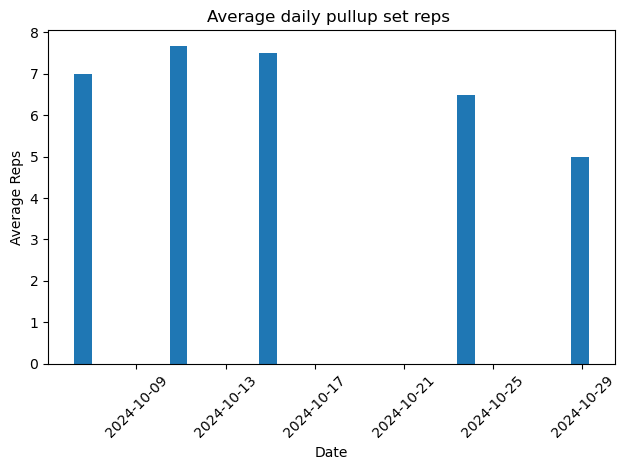

In [8]:
import utils
import importlib
importlib.reload(utils)

utils.plot_average_pullups_per_day()

This bar graph shows me the average number of reps I got in a set spread out by each day I did pull ups in october which was 5 times. Now I can easily look at progress of my pull up and see if it was an effectice exercise. I then wanted to look at my volume throughout my time here at gonzaga.

/Users/abemesh/Desktop/da_8/utils.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2024['Date'] = data_2024['Date'].dt.date


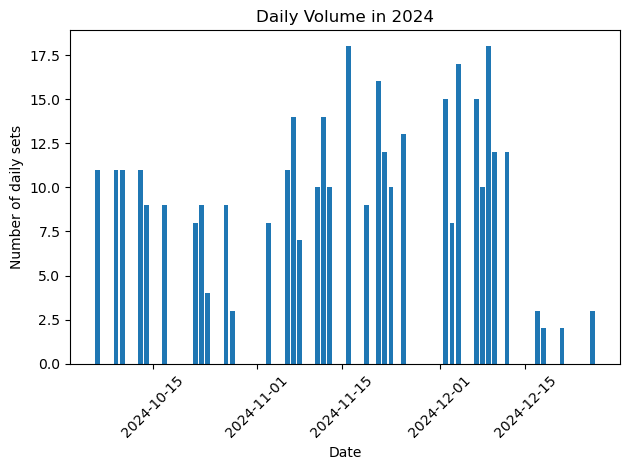

In [9]:

utils.plot_daily_volume_2024()

In this graph we can see my daily volume which is tracked based on the number of sets I did per day. In october my daily volume was around 10 then in late november to mid december my volume begins to increase to about 15 per day. 

Then in late december my volume decreases to below 5 per day. An important thing to note is that I had a injured ankle at the begining of the year so as I got into november I wasnt limited to working out due to ankle pain. Its cool to see that healing from and injury could possible be the causing differ in volume. Next I will be looking at my most frequent excerise, the bench press which I did the most compared to any other exercises. Also about when I went on winter break, 12-13 my volume drops which is expected because I probably didnt workout much at the start of winter break.

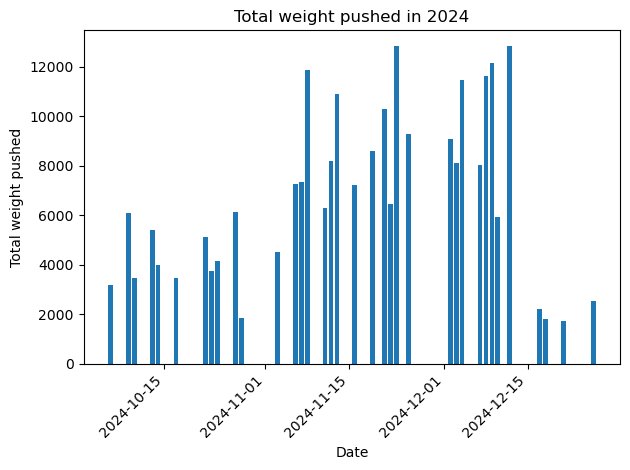

In [10]:
import utils
import importlib
importlib.reload(utils)
utils.plot_total_weight_pushed_per_day_2024()

In this graph I look at the total amount of weight I moved every day. This was done by multipying the reps and weight per day. This was cool to see, it also lines up well with the volume graph. Next I will look at weight pushed per set

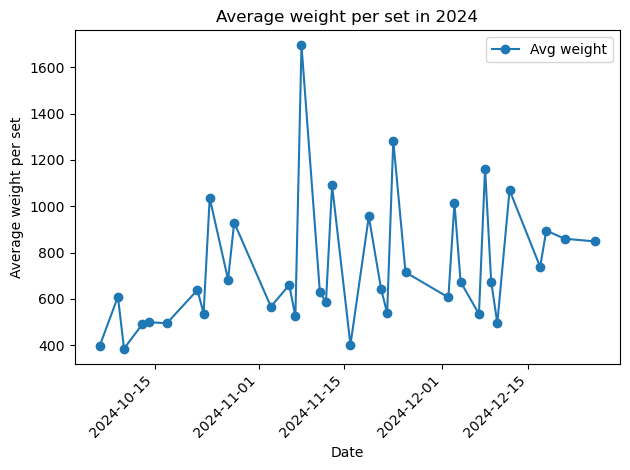

In [11]:
import utils
import importlib
importlib.reload(utils)

utils.plot_average_weight_per_set_2024()

This graph shows the data of the amount of weight I pushed per set/exercise. This is cool to see and also dosnt really line up with the weight pushed per day graph which is intresting to see I wonder why that is. I can se a positive trend of average weight per set except that one outlier day as the graph is very jumpy but the begineing to the end it slowly increased to about 2x average weight.

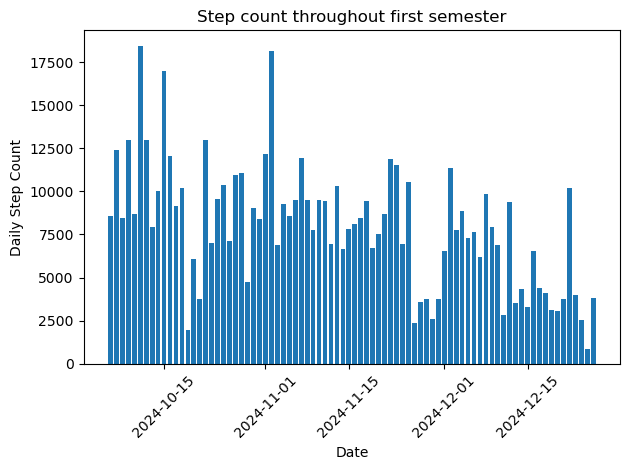

In [12]:
utils.plot_daily_steps(daily_steps_df)

This graph is my data from apple health which tracked my daily step count throughout the first semester. As you can see there seem to be a slight negative trend, which makes sense as it became pretty cold during this time so I stayed inside alot and didnt wlak outside much. Also at the end of the semester I was really working out so this was cool to see in a graph.     


##### I will now be testing multiply hypothesis using my cleaned data     
### What statistical hypothesis tests are you computing


The first hypthesis I will be testing is if I made progress in  daily total weight pushed/ total weight pushed per workout, to see if the total weight I was lifting at the end of the semester was less then, greater then or equal to the weight I was pushing at the start of the semester. This will give me an idea if I increased strength,decreased in strength or kept a constistent level of strength.

Null hypothesis : The average total weight pushed per day at the start of the semester is equal weight pushed per day at the end of semester
Alternative hypothesis: The average weight pushed per day is different the the average weight pushed at the end of the semester. 
T
his is a two tailed depdendent test, with a signfinance level of .05.

Step 1:
$ H₀: Start\mu= End\mu    $     
$H₁: Start\mu ≠ End\mu   $

Step 2:
 α = 0.05
 Step 3:     

In [13]:
import utils
import importlib
importlib.reload(utils)

# Perform the t-test
t_stat= utils.t_test_weight_pushed(cleaned)
print(t_stat)



TtestResult(statistic=-2.240332255307274, pvalue=0.03601215483979387, df=21.0)


Step 4: 
t crit = +/-2.0796
If T_stat is less then -2.08 or greater then 2.08, then we rejected the null hypothesis     
Else, if it falls inbetween we failed to reject the null hypothesis.      
Step 5:    
-2.24 < -2.08, we rejected the null hypothesis, meaning the start and end average weight pushed throughtout the semester is not equivilient.

My Second hypothesis will test if my daily steps increased throughout the first semester. I will be using a one tailed depdendent test to test this with a signficnace of .05. This will give me an idea if I become more fit and active throughout the semmester or if I became more of a stay at home person who didnt leave his dorm at all :C. 

Step 1:     
$ H₀: End\mu \leq Start\mu    $     
$H₁: Endt\mu > Start\mu   $
Step 2:      
a = .05      
Step 3:    

In [14]:
import utils
import importlib
importlib.reload(utils)

t_stat = utils.t_test_daily_steps(daily_steps_df)
print(t_stat)

TtestResult(statistic=-5.454509990304142, pvalue=2.7564344546733067e-06, df=40)


Step 4:      
T Critical value is 1.684
If T stat is > 1.684, then we reject the null hypothesis    
If T stat is <= 1.684, the we fail to reject the null hypothesis     
Step 5:        
-5.45 < 1.684, so we failed to reject the null hypothesis, 

* Result: This meaning my steps did not increase by the end of the semester. Which makes sense as I do remember staying inside more and I didnt really make choices to be more active throughout the semester so it makes sense there wasnt enough evidence for a signinicent difference


### Classification Results     
##### Attribute I'm using as class information
The attritube I'm using as the class information is `Workout Name`. Originally I planned on being able to have a classifer that can predict the type of workout I did out of my workout split. For context my workout split consists of 3 different workout days taht I continously rotated. Push, Pull, and legs, these 3 being different groups of exercises I did on seperate days. It would predict the workout based on the features from the workout session. But unforencently the tracking app data for some reason didnt track this but allows me to track when in the day I worked out. So I will be looking at the categories Morning Wokrout, Midday workout, afternoon workout, and evening workout, to see when I most commonly workout.

##### What is the distribution of the class labels?


 

In [15]:
workout_c = cleaned['Workout Name'].value_counts()
workout_p = cleaned['Workout Name'].value_counts(normalize=True) * 100
print("Workout name data distribution:\n", workout_c)
print("\nWorkout name frequency percentages:\n", workout_p)

Workout name data distribution:
 Workout Name
Evening Workout      282
Afternoon Workout     47
Midday Workout        13
Pull                  11
Morning Workout       11
Name: count, dtype: int64

Workout name frequency percentages:
 Workout Name
Evening Workout      77.472527
Afternoon Workout    12.912088
Midday Workout        3.571429
Pull                  3.021978
Morning Workout       3.021978
Name: proportion, dtype: float64


Based on my data above, my distrubtion for time based workouts is pretty skewed:
* Eveneing Workout: 77.5%
* Afternoon Workout: 12.9%
* Midday Workout: 3.5%
* Morning Workout 3%
* Workout w/o time connection 3%
This could possibly be a class imblanace due to evening workouts being such a high percent.
##### What are your hypotheses about the predictions?
My main hypothesis is that the time compoents taken from the Date coloum will be the most significant predictor for Workout Name, like 7pm> in the date coloum with probably connect with evening workout.      
##### How are you evaluating the performance of your kNN and decision tree classifier? How do their results compare?

I'm going to mainly focus on the accuracy results to see if my data was actually a bit sckewed, and maybe preciion to understand performance of less frequent Workout names. 

Knn Accurracy: 0.8028169014084507
Decision Tree: 0.8028169014084507


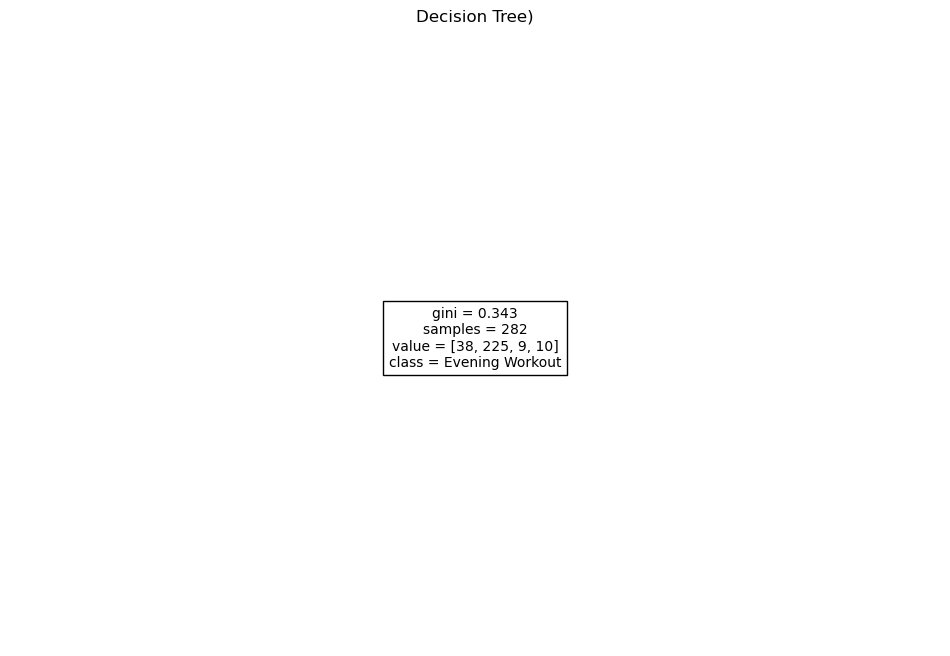

In [16]:
utils.run_classification_and_plot_tree(cleaned)


I evaulted the performance of the knn and decision tree classifieres using the accuraccy outputs. I was able to get an accuraccy in the 80's which is good, but at the same time my desicion tree graph was one square so it basically automattially assumes that I'm working out in the evening. Unforcnehtly this is to be expected to do how skewed my data is, I mean this just shows how much I enjoy to workout at night I didnt realize it was to this degree that almost 80 percent of workouts were at night. My Knn and decision tree accuraccy where very similar which is to be expected due to having a smaller data set and variation. As said before this higha accuracy may be misleading due to it being heavily swayed by majority of data being in Evening workouts. As seen the descion tree failed to make branches, so the decision tree wasnt able to distringuish very well between hours of the day data, causing the madol to default to the majority(evening workout). If my data was more balanced around 20-30 percent for each type of workout I beleive the branching would be better and more reasonable, but due to be only liking to workout at night this isnt possible.     

##### What are the challenges you experienced with classification?

The main challange, as I talked about above was the large imbalance in my workout name data, with evening workouts being almost 80 percents of the rows, causing high accuraccy scores due to the models not being able to predict the other workout names like morning and afternoon. This is intresting to see the limits of the model with skewed data, but I was able to learn the limits to these models and where they are weaker in testing data. So it was a real challange of only using hour to as a predicition feature, as it seem to be insuffieicent for my desciisin tree algorithim unforcentently. 

### Conclusion

##### Classification conclusion: 
My classification planned on being able to predict the time of day a workout occured, morning, midday, afternoon, or evening, using the Hour of the workout start time as the main feature. Using Knn and decision tree classifiers to do this, both of them had similar results of about 80%. But this accurracy was mainly because the model was using skewed data and just ended up consistently choosing the most common data output (evening workout). A key thing I saw was the decision tree only had one box, so it failed to branch out and distinguish the other workout names/times. If i could improve performance possibly could have somehow manually sorted data based on what I beleived I was doing on those day and manualy inputting push,pull, legs but that would be going against the point of the project to automate this stuff.
##### Effect on stakeholders
So as I said above, the only real stakeholder is myself as this is a very personal data set based on a very personal goal. Im acutally happy with what I saw as I was able to see my activity and health progression in my first semester of college. Esspically with the scary legend of the freshman 15 I was able to see how college life and working out effected my life from the very begginging of coming to college to the end of my first semester, I learned alot about myself and enjoyed looking back at the past.
##### Sources
1. "Strong" on the app store
2. "Apple Health" also on the app store
3. https://medium.com/internet-of-technology/how-to-extract-and-analyze-apple-health-data-a-practical-python-guide-4b9ddbade37f
